In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the dataset to check its structure
file_path = '/content/drive/MyDrive/rocs_individual_assessment_data.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()

,country.name,app.name,rank,date,ldc
0,Albania,EzCash: Free In-Game Currency & Gift Cards,1,2021-08-01,False
1,Albania,TikTok,2,2021-08-01,False
2,Albania,Snapchat,3,2021-08-01,False
3,Albania,Instagram,4,2021-08-01,False
4,Albania,VPN Free Max-unlimited & Fast proxy master,5,2021-08-01,False


<ipython-input-3-d1271434c777>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=country_popularity, x='is_ldc', y='avg_rank', palette="Set2")


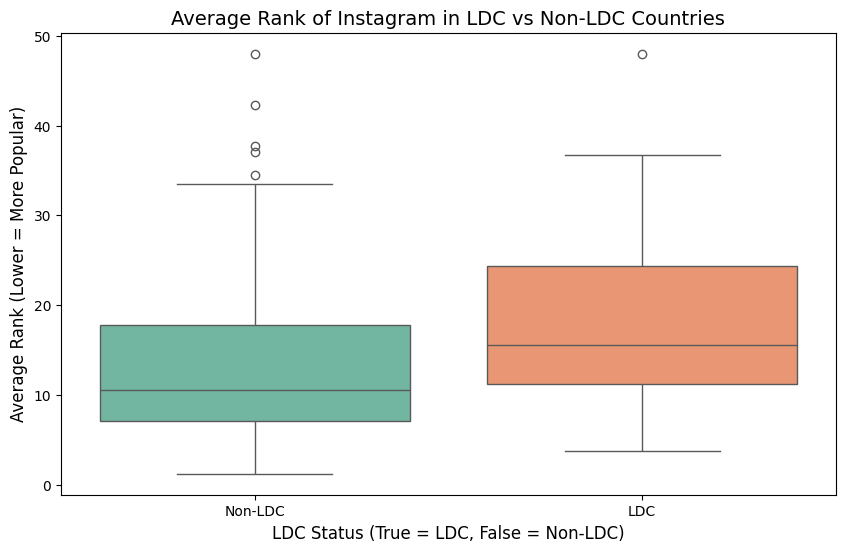

        count       mean        std       min        25%        50%  \
is_ldc                                                                
False   120.0  13.549205   9.115151  1.225806   7.112903  10.516129   
True     20.0  19.119295  11.422936  3.741935  11.217742  15.516129   

              75%   max  
is_ldc                   
False   17.766129  48.0  
True    24.354839  48.0  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Instagram data
instagram_data = data[data['app.name'] == 'Instagram']

# Calculate average rank by country
country_popularity = instagram_data.groupby(['country.name', 'ldc'])['rank'].mean().reset_index()
country_popularity.columns = ['country', 'is_ldc', 'avg_rank']

# Visualize the difference in average rank between LDC and non-LDC groups
plt.figure(figsize=(10, 6))
sns.boxplot(data=country_popularity, x='is_ldc', y='avg_rank', palette="Set2")
plt.title("Average Rank of Instagram in LDC vs Non-LDC Countries", fontsize=14)
plt.xlabel("LDC Status (True = LDC, False = Non-LDC)", fontsize=12)
plt.ylabel("Average Rank (Lower = More Popular)", fontsize=12)
plt.xticks(ticks=[0, 1], labels=["Non-LDC", "LDC"], fontsize=10)
plt.show()

# Descriptive statistics
ldc_stats = country_popularity.groupby('is_ldc')['avg_rank'].describe()
print(ldc_stats)



In [ ]:
# Reload the necessary libraries
import pandas as pd
from scipy.stats import mannwhitneyu, shapiro

# Reload the dataset
file_path = '/content/drive/MyDrive/rocs_individual_assessment_data.csv'
data = pd.read_csv(file_path)

# Filter for Facebook data
facebook_data = data[data['app.name'] == 'Facebook']

# Calculate mean rank for Facebook by country and LDC status
facebook_popularity = facebook_data.groupby(['country.name', 'ldc'])['rank'].mean().reset_index()
facebook_popularity.columns = ['country', 'is_ldc', 'avg_rank']

# Separate the groups: LDC and Non-LDC
ldc_group = facebook_popularity[facebook_popularity['is_ldc'] == True]['avg_rank']
non_ldc_group = facebook_popularity[facebook_popularity['is_ldc'] == False]['avg_rank']

# Test for normality using Shapiro-Wilk test
ldc_normality = shapiro(ldc_group)
non_ldc_normality = shapiro(non_ldc_group)

# Perform the Mann-Whitney U test
mannwhitney_test_statistic, mannwhitney_p_value = mannwhitneyu(ldc_group, non_ldc_group, alternative='two-sided')

(ldc_normality, non_ldc_normality), (mannwhitney_test_statistic, mannwhitney_p_value)


((ShapiroResult(statistic=0.9658294614338864, pvalue=0.6655219048854303),
  ShapiroResult(statistic=0.9381325991247156, pvalue=0.00030638133235982244)),
 (602.0, 0.018306571654886323))

In [ ]:
# Re-apply Mann-Whitney U test for clarity
mannwhitney_test_statistic, mannwhitney_p_value = mannwhitneyu(ldc_group, non_ldc_group, alternative='two-sided')

mannwhitney_test_statistic, mannwhitney_p_value


(602.0, 0.018306571654886323)

<ipython-input-6-1a12c7315ffc>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=facebook_popularity, x='group', y='avg_rank', palette="Set1")


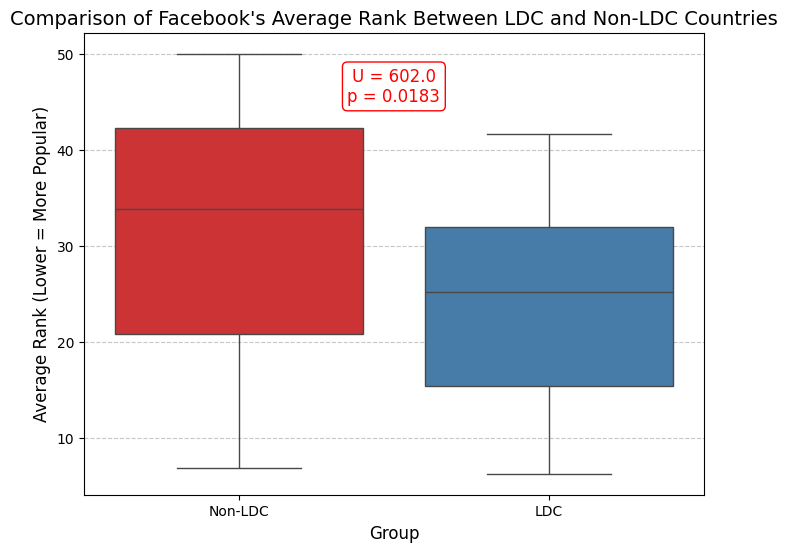

(602.0, 0.018306571654886323)

In [ ]:
# Reloading the necessary libraries and dataset to perform the Mann-Whitney U Test and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Reload the dataset
file_path = '/content/drive/MyDrive/rocs_individual_assessment_data.csv'
data = pd.read_csv(file_path)

# Filter for Facebook data
facebook_data = data[data['app.name'] == 'Facebook']

# Calculate mean rank for Facebook by country and LDC status
facebook_popularity = facebook_data.groupby(['country.name', 'ldc'])['rank'].mean().reset_index()
facebook_popularity.columns = ['country', 'is_ldc', 'avg_rank']

# Separate the groups: LDC and Non-LDC
ldc_group = facebook_popularity[facebook_popularity['is_ldc'] == True]['avg_rank']
non_ldc_group = facebook_popularity[facebook_popularity['is_ldc'] == False]['avg_rank']

# Perform the Mann-Whitney U test
mannwhitney_test_statistic, mannwhitney_p_value = mannwhitneyu(ldc_group, non_ldc_group, alternative='two-sided')

# Visualization for Mann-Whitney U Test Results
plt.figure(figsize=(8, 6))

# Add group column for plotting
facebook_popularity['group'] = facebook_popularity['is_ldc'].replace({True: 'LDC', False: 'Non-LDC'})

# Boxplot for comparison of ranks
sns.boxplot(data=facebook_popularity, x='group', y='avg_rank', palette="Set1")
plt.title("Comparison of Facebook's Average Rank Between LDC and Non-LDC Countries", fontsize=14)
plt.xlabel("Group", fontsize=12)
plt.ylabel("Average Rank (Lower = More Popular)", fontsize=12)
plt.annotate(f'U = {mannwhitney_test_statistic:.1f}\n'
             f'p = {mannwhitney_p_value:.4f}',
             xy=(0.5, max(facebook_popularity['avg_rank']) - 5),
             fontsize=12, color='red', ha='center', bbox=dict(boxstyle="round", facecolor="white", edgecolor="red"))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

(mannwhitney_test_statistic, mannwhitney_p_value)


<ipython-input-7-f492a4caad46>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pakistan_instagram_data['date'] = pd.to_datetime(pakistan_instagram_data['date'])


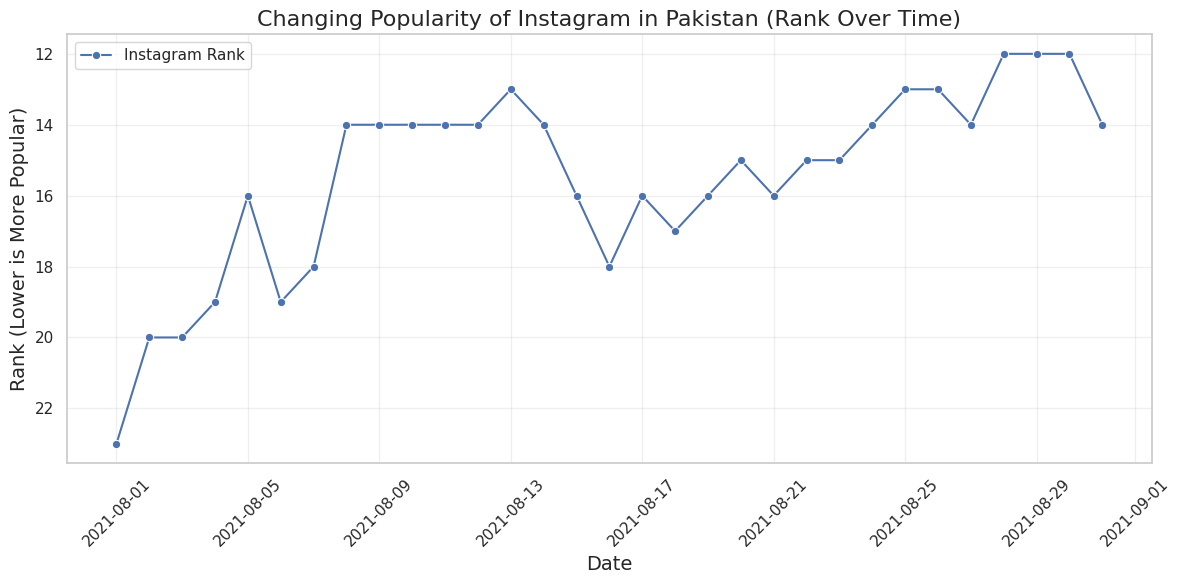

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv(file_path)

# Filter data for Instagram in Pakistan
pakistan_instagram_data = data[(data['country.name'] == 'Pakistan') & (data['app.name'] == 'Instagram')]

# Convert the 'date' column to a datetime format
pakistan_instagram_data['date'] = pd.to_datetime(pakistan_instagram_data['date'])

# Sort the data by date
pakistan_instagram_data = pakistan_instagram_data.sort_values(by='date')

# Set the style for the plot
sns.set(style="whitegrid")

# Create a more detailed visualization using Seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=pakistan_instagram_data, x='date', y='rank', marker='o', label='Instagram Rank')

# Invert y-axis for ranks (lower ranks are more popular)
plt.gca().invert_yaxis()

# Enhance the visualization
plt.title('Changing Popularity of Instagram in Pakistan (Rank Over Time)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Rank (Lower is More Popular)', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)

# Show the plot
plt.show()


In [ ]:
# Calculate descriptive statistics for Instagram's popularity in Pakistan
descriptive_stats = pakistan_instagram_data['rank'].describe()

# Additional metrics for completeness
mode_rank = pakistan_instagram_data['rank'].mode()[0]  # Most frequent rank
iqr = descriptive_stats['75%'] - descriptive_stats['25%']  # Interquartile Range (IQR)

# Display the summary
print("Descriptive Statistics for Instagram's Popularity in Pakistan:")
print(f"Mean Rank: {descriptive_stats['mean']}")
print(f"Median Rank: {pakistan_instagram_data['rank'].median()}")
print(f"Standard Deviation: {descriptive_stats['std']}")
print(f"Minimum Rank: {descriptive_stats['min']}")
print(f"Maximum Rank: {descriptive_stats['max']}")
print(f"25th Percentile (Q1): {descriptive_stats['25%']}")
print(f"75th Percentile (Q3): {descriptive_stats['75%']}")
print(f"Mode Rank: {mode_rank}")
print(f"Interquartile Range (IQR): {iqr}")


Descriptive Statistics for Instagram's Popularity in Pakistan:
Mean Rank: 15.483870967741936
Median Rank: 15.0
Standard Deviation: 2.6692192084569806
Minimum Rank: 12.0
Maximum Rank: 23.0
25th Percentile (Q1): 14.0
75th Percentile (Q3): 16.5
Mode Rank: 14
Interquartile Range (IQR): 2.5


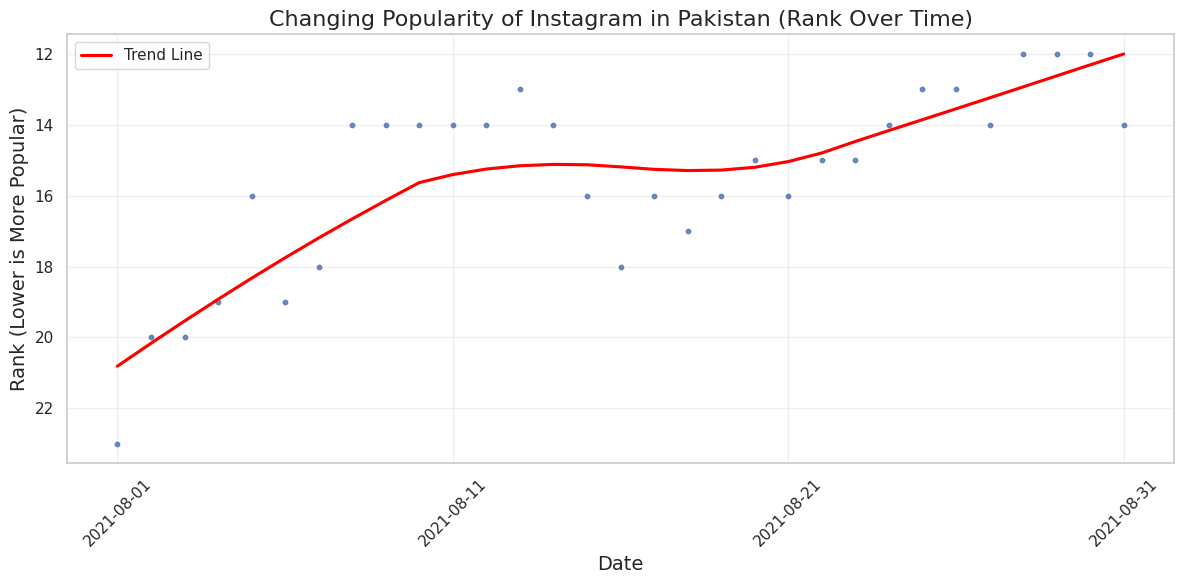

In [ ]:
# Correcting the typo and plotting again
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 6))

# Convert 'date' to numeric representation using toordinal()
# and store it in 'date_numeric' column
pakistan_instagram_data['date_numeric'] = pakistan_instagram_data['date'].apply(lambda date: date.toordinal())

sns.regplot(data=pakistan_instagram_data, x='date_numeric', y='rank', lowess=True,
            scatter_kws={'s': 10}, line_kws={'color': 'red', 'label': 'Trend Line'})

# Invert y-axis for ranks (lower ranks are more popular)
plt.gca().invert_yaxis()

# Enhance the visualization
plt.title('Changing Popularity of Instagram in Pakistan (Rank Over Time)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Rank (Lower is More Popular)', fontsize=14)

# Replace numeric dates with formatted date labels
date_labels = pakistan_instagram_data['date'].dt.strftime('%Y-%m-%d')
plt.xticks(
    ticks=pakistan_instagram_data['date_numeric'][::10],
    labels=date_labels[::10],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)

# Show the plot
plt.show()

In [ ]:
from scipy.stats import spearmanr

# Apply Spearman's Rank Correlation test
spearman_corr, spearman_p_value = spearmanr(pakistan_instagram_data['date_numeric'], pakistan_instagram_data['rank'])

# Display the test statistic and p-value
print("Spearman's Rank Correlation Coefficient (ρ):", spearman_corr)
print("p-value:", spearman_p_value)

# Interpretation
if spearman_p_value < 0.05:
    print("The result is statistically significant, indicating a significant relationship between time and rank.")
else:
    print("The result is not statistically significant.")


Spearman's Rank Correlation Coefficient (ρ): -0.6726909952719768
p-value: 3.388231243751595e-05
The result is statistically significant, indicating a significant relationship between time and rank.
